<a href="https://colab.research.google.com/github/alperdinceler/Machine-learning/blob/main/Palmer_Penguins_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Palmer Penguins EDA**

In [ ]:
import kagglehub
path = kagglehub.dataset_download("satyajeetrai/palmer-penguins-dataset-for-eda")

Using Colab cache for faster access to the 'palmer-penguins-dataset-for-eda' dataset.


In [ ]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


In [ ]:
df = pd.read_csv(path + "/penguins.csv")

print('🐧 Penguen Verisi Özet Bilgileri')
print('='*50)
print(f'Boyut : {df.shape[0]} satır, {df.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df.memory_usage(deep=True).sum()/1024:.2f} KB')


🐧 Penguen Verisi Özet Bilgileri
Boyut : 344 satır, 9 sütun
Bellek kullanımı: 71.34 KB


In [ ]:
df.head()


,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,male,2007
1,1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,female,2007
2,2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,female,2007


In [ ]:
df.tail()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
339,339,Chinstrap,Dream,55.80,19.80,207.00,4000.00,male,2009
340,340,Chinstrap,Dream,43.50,18.10,202.00,3400.00,female,2009
341,341,Chinstrap,Dream,49.60,18.20,193.00,3775.00,male,2009
342,342,Chinstrap,Dream,50.80,19.00,210.00,4100.00,male,2009
343,343,Chinstrap,Dream,50.20,18.70,198.00,3775.00,female,2009


In [ ]:
df.sample(5)

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
72,72,Adelie,Torgersen,39.60,17.20,196.00,3550.00,female,2008
137,137,Adelie,Dream,40.20,20.10,200.00,3975.00,male,2009
21,21,Adelie,Biscoe,37.70,18.70,180.00,3600.00,male,2007
198,198,Gentoo,Biscoe,45.50,13.90,210.00,4200.00,female,2008
154,154,Gentoo,Biscoe,48.70,14.10,210.00,4450.00,female,2007


In [ ]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df.columns,
    'veri tipi': df.dtypes.values,
    'null değeri':df.isnull().sum().values,
    'null oranı(%)': (df.isnull().sum().values/len(df)*100).round(2),
    'unıque': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
            sütun veri tipi  null değeri  null oranı(%)  unıque
               id     int64            0           0.00     344
          species    object            0           0.00       3
           island    object            0           0.00       3
   bill_length_mm   float64            2           0.58     164
    bill_depth_mm   float64            2           0.58      80
flipper_length_mm   float64            2           0.58      55
      body_mass_g   float64            2           0.58      94
              sex    object           11           3.20       2
             year     int64            0           0.00       3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [ ]:
df.shape

(344, 9)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,344.00,171.50,99.45,0.00,85.75,171.50,257.25,343.00
bill_length_mm,342.00,43.92,5.46,32.10,39.23,44.45,48.50,59.60
bill_depth_mm,342.00,17.15,1.97,13.10,15.60,17.30,18.70,21.50
flipper_length_mm,342.00,200.92,14.06,172.00,190.00,197.00,213.00,231.00
body_mass_g,342.00,4201.75,801.95,2700.00,3550.00,4050.00,4750.00,6300.00
year,344.00,2008.03,0.82,2007.00,2007.00,2008.00,2009.00,2009.00


In [ ]:
df.describe(include=["object","category"]).T

,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,333,2,male,168


In [ ]:
ayisal_sutunlar = df.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
eksik =df.isnull().sum()
eksik_oranı=(eksik/len(df)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)


,eksik_sayı,eksik_oran
sex,11,3.20
body_mass_g,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
bill_length_mm,2,0.58
id,0,0.00
island,0,0.00
species,0,0.00
year,0,0.00


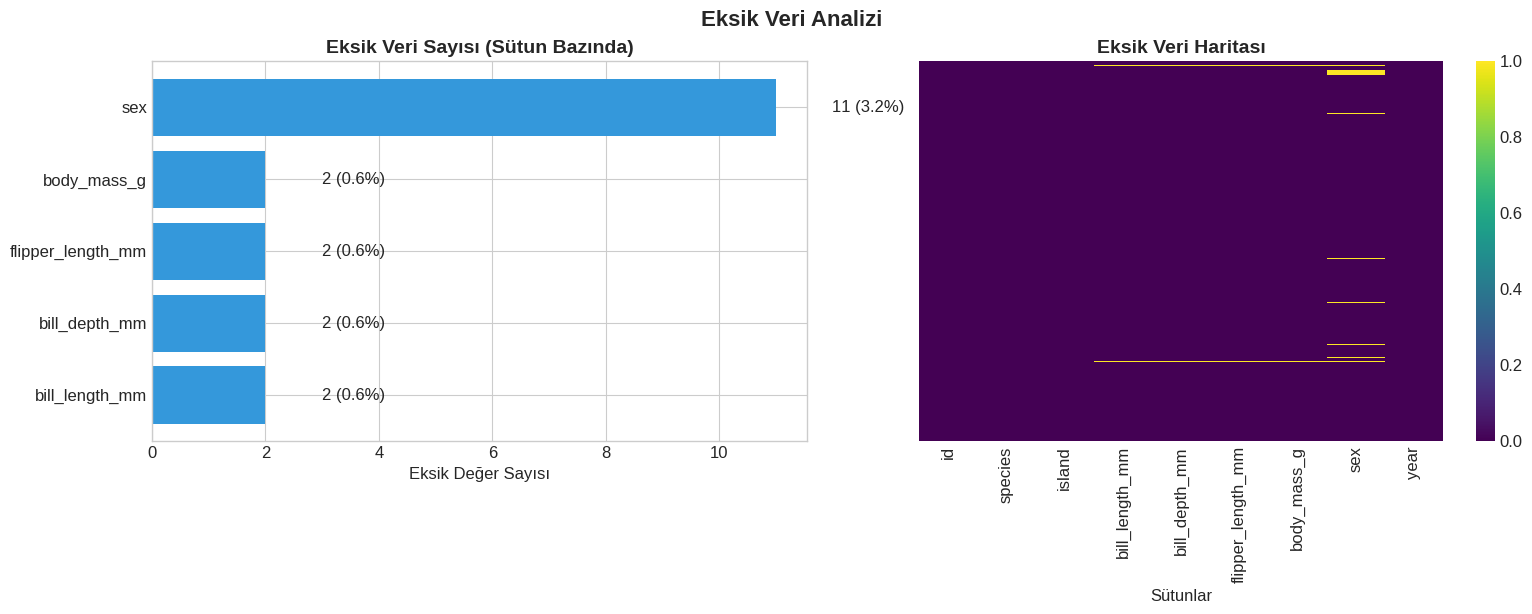

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# eksik veri stratejileri

In [ ]:
#aykırı değer fazla olduğunda kullanılır
df_temiz= df.copy()

bodymass_medyan =df_temiz['body_mass_g'].median()

df_temiz['body_mass_g'].fillna(bodymass_medyan, inplace=True)


bill_length_medyan =df_temiz['bill_length_mm'].median()

df_temiz['bill_length_mm'].fillna(bill_length_medyan, inplace=True)


bill_medyan =df_temiz['bill_depth_mm'].median()

df_temiz['bill_depth_mm'].fillna(bill_medyan, inplace=True)


flipper_medyan =df_temiz['flipper_length_mm'].median()
df_temiz['flipper_length_mm'].fillna(flipper_medyan, inplace=True)

df_temiz.isnull().sum()

,0
id,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,11
year,0


In [ ]:
df_temiz['sex']=df_temiz['sex'].astype(str).str[0]
df_temiz['sex'].fillna('Belirsiz',inplace=True)
print(df_temiz['sex'].value_counts())


sex
m    168
f    165
n     11
Name: count, dtype: int64


## tek analiz

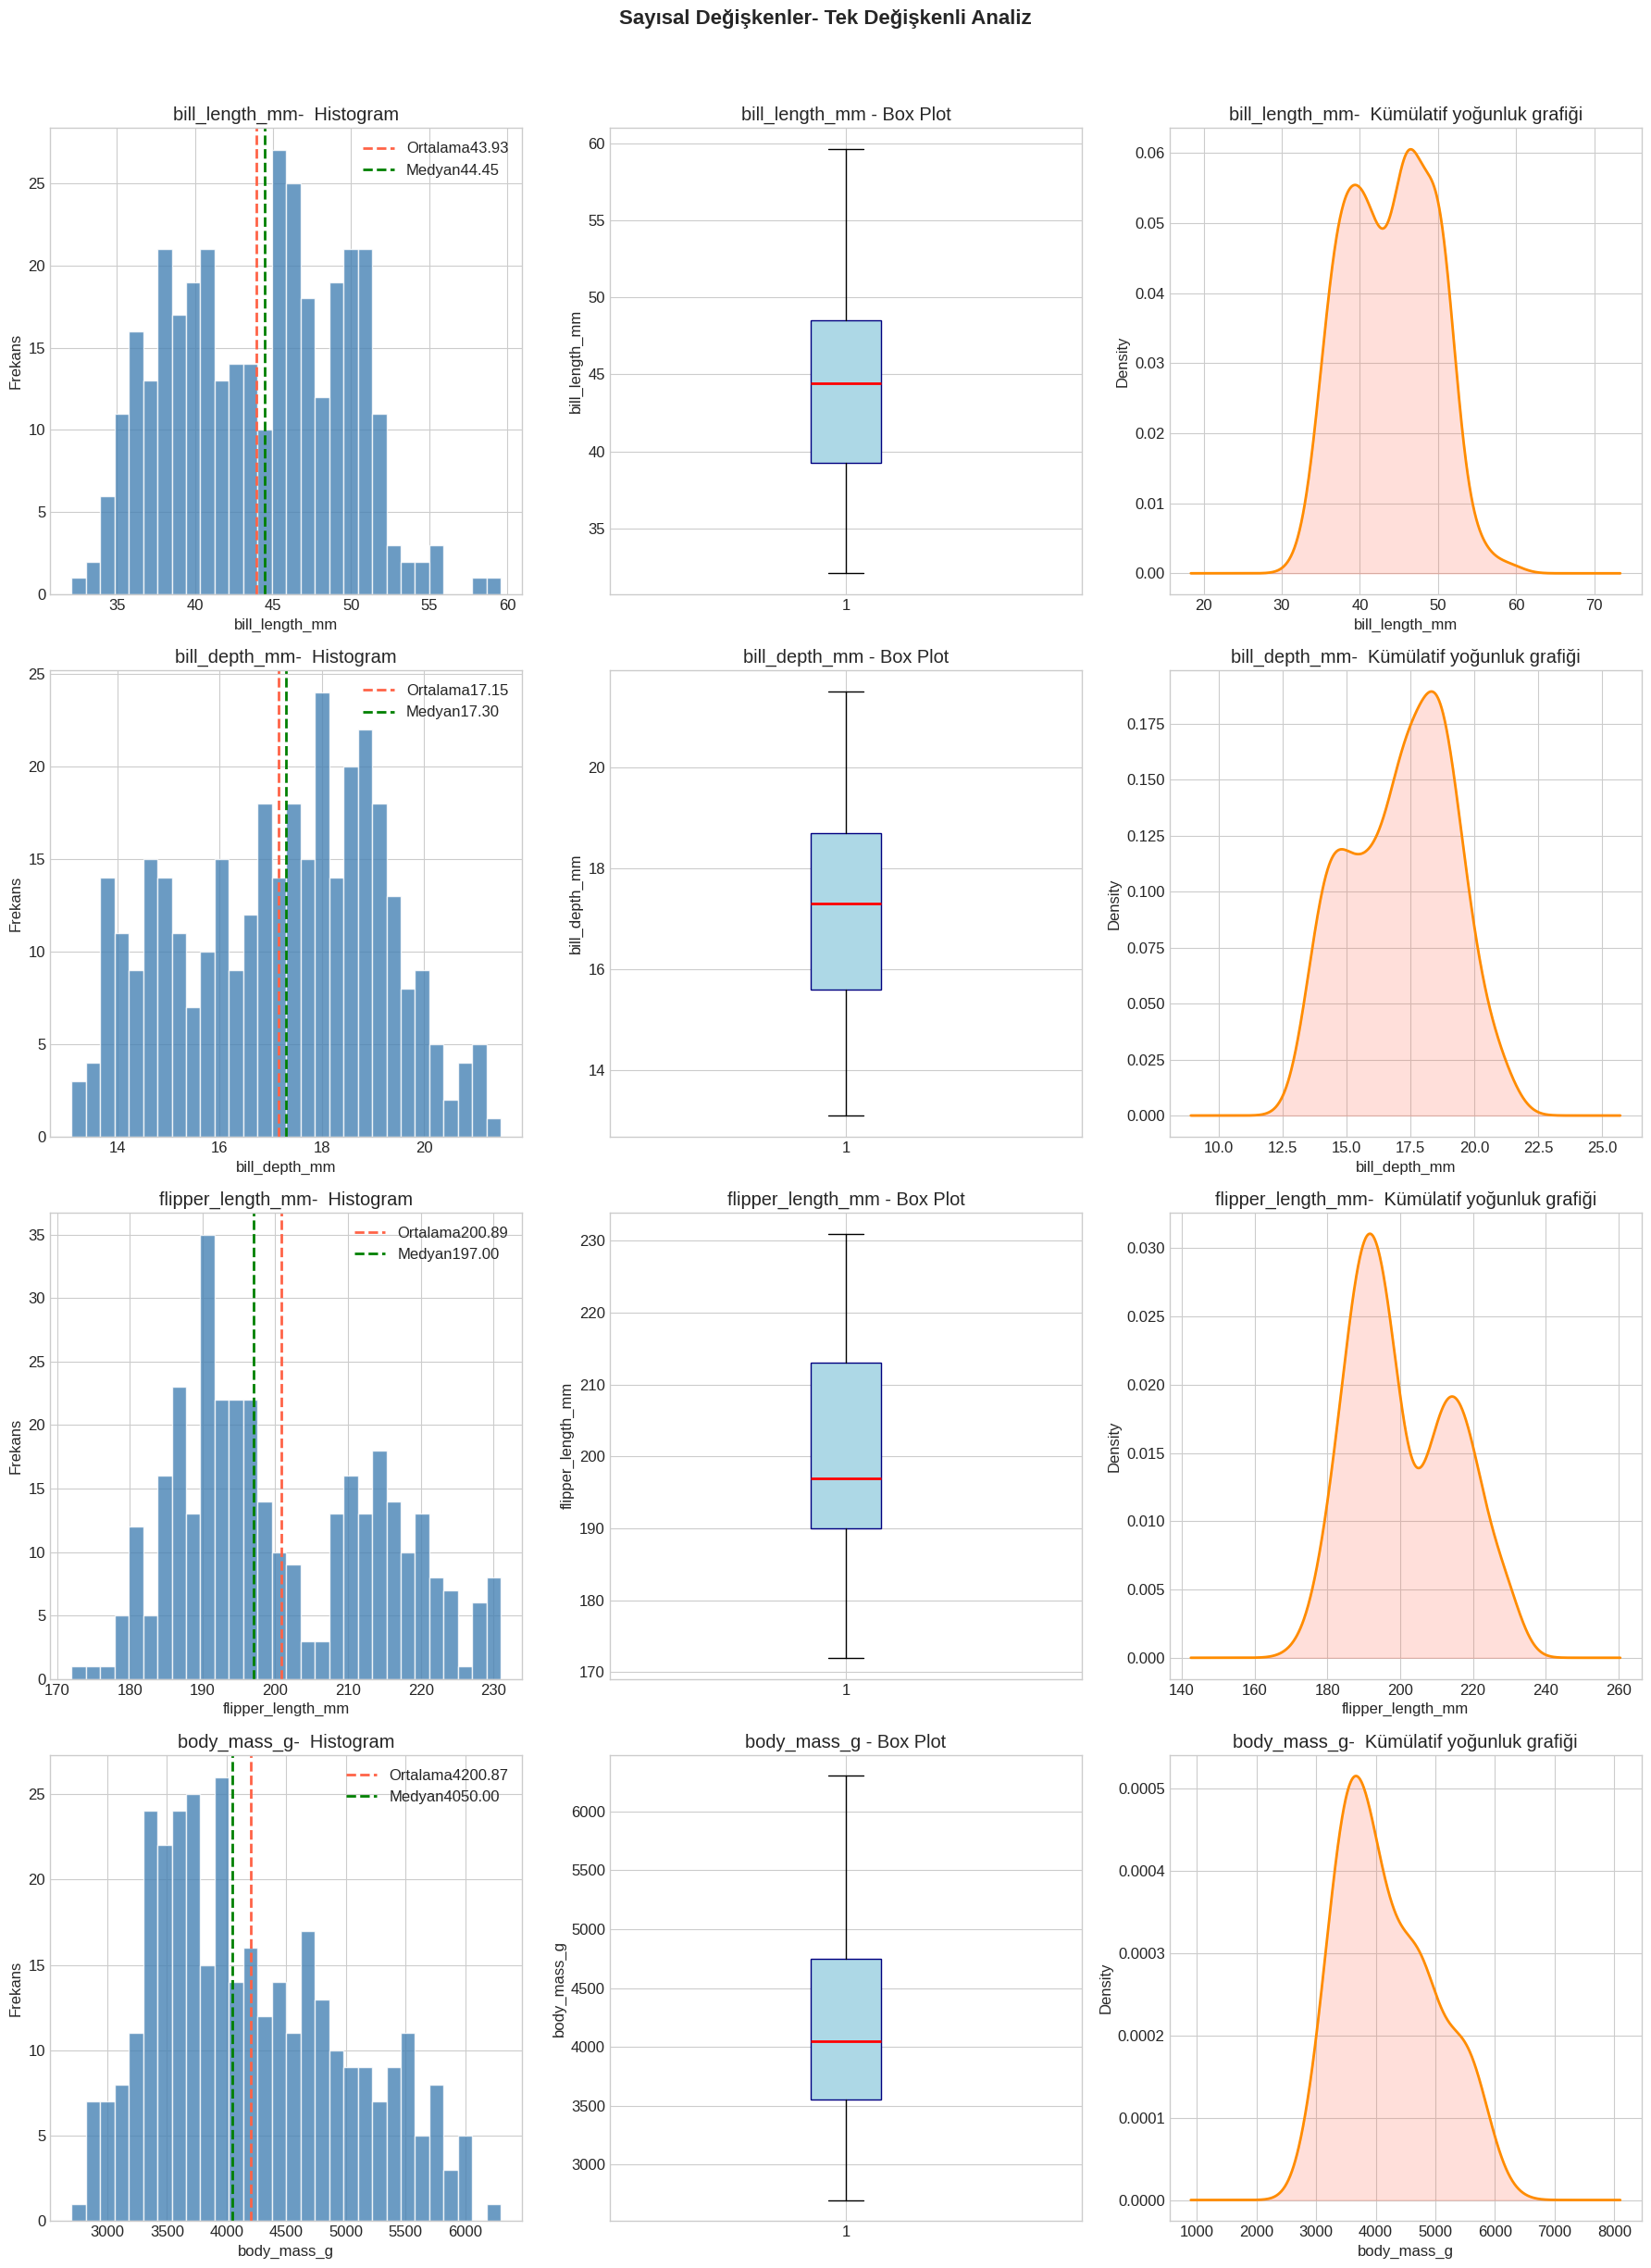

In [ ]:

sayisal_kolonlar =['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
  veri = df_temiz[kolon].dropna()

  axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
  axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
  axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
  axes[i,0].set_title(f'{kolon}-  Histogram')
  axes[i,0].legend()
  axes[i,0].set_xlabel(kolon)
  axes[i,0].set_ylabel('Frekans')

      # Box plot
  axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
  axes[i, 1].set_title(f'{kolon} - Box Plot')
  axes[i, 1].set_ylabel(kolon)


  veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
  axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                        axes[i,2].lines[0].get_ydata(),
                        color='tomato',alpha=0.2)
  axes[i,2].set_title(f'{kolon}-  Kümülatif yoğunluk grafiği')
  axes[i,2].set_xlabel(kolon)


plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_temiz[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * BILL_LENGTH_MM
Ortalama: 43.93
Medyan: 44.45
Standart Sapma: 5.44
Minimum: 32.10
Maksimum: 59.60
Varyans: 29.63
Skewness(Çarpıklık): 0.05
Kurtosis(Basıklık): -0.86
IQR: 9.23

 * BILL_DEPTH_MM
Ortalama: 17.15
Medyan: 17.30
Standart Sapma: 1.97
Minimum: 13.10
Maksimum: 21.50
Varyans: 3.88
Skewness(Çarpıklık): -0.15
Kurtosis(Basıklık): -0.89
IQR: 3.10

 * FLIPPER_LENGTH_MM
Ortalama: 200.89
Medyan: 197.00
Standart Sapma: 14.02
Minimum: 172.00
Maksimum: 231.00
Varyans: 196.67
Skewness(Çarpıklık): 0.35
Kurtosis(Basıklık): -0.97
IQR: 23.00

 * BODY_MASS_G
Ortalama: 4200.87
Medyan: 4050.00
Standart Sapma: 799.70
Minimum: 2700.00
Maksimum: 6300.00
Varyans: 639514.54
Skewness(Çarpıklık): 0.47
Kurtosis(Basıklık): -0.70
IQR: 1200.00


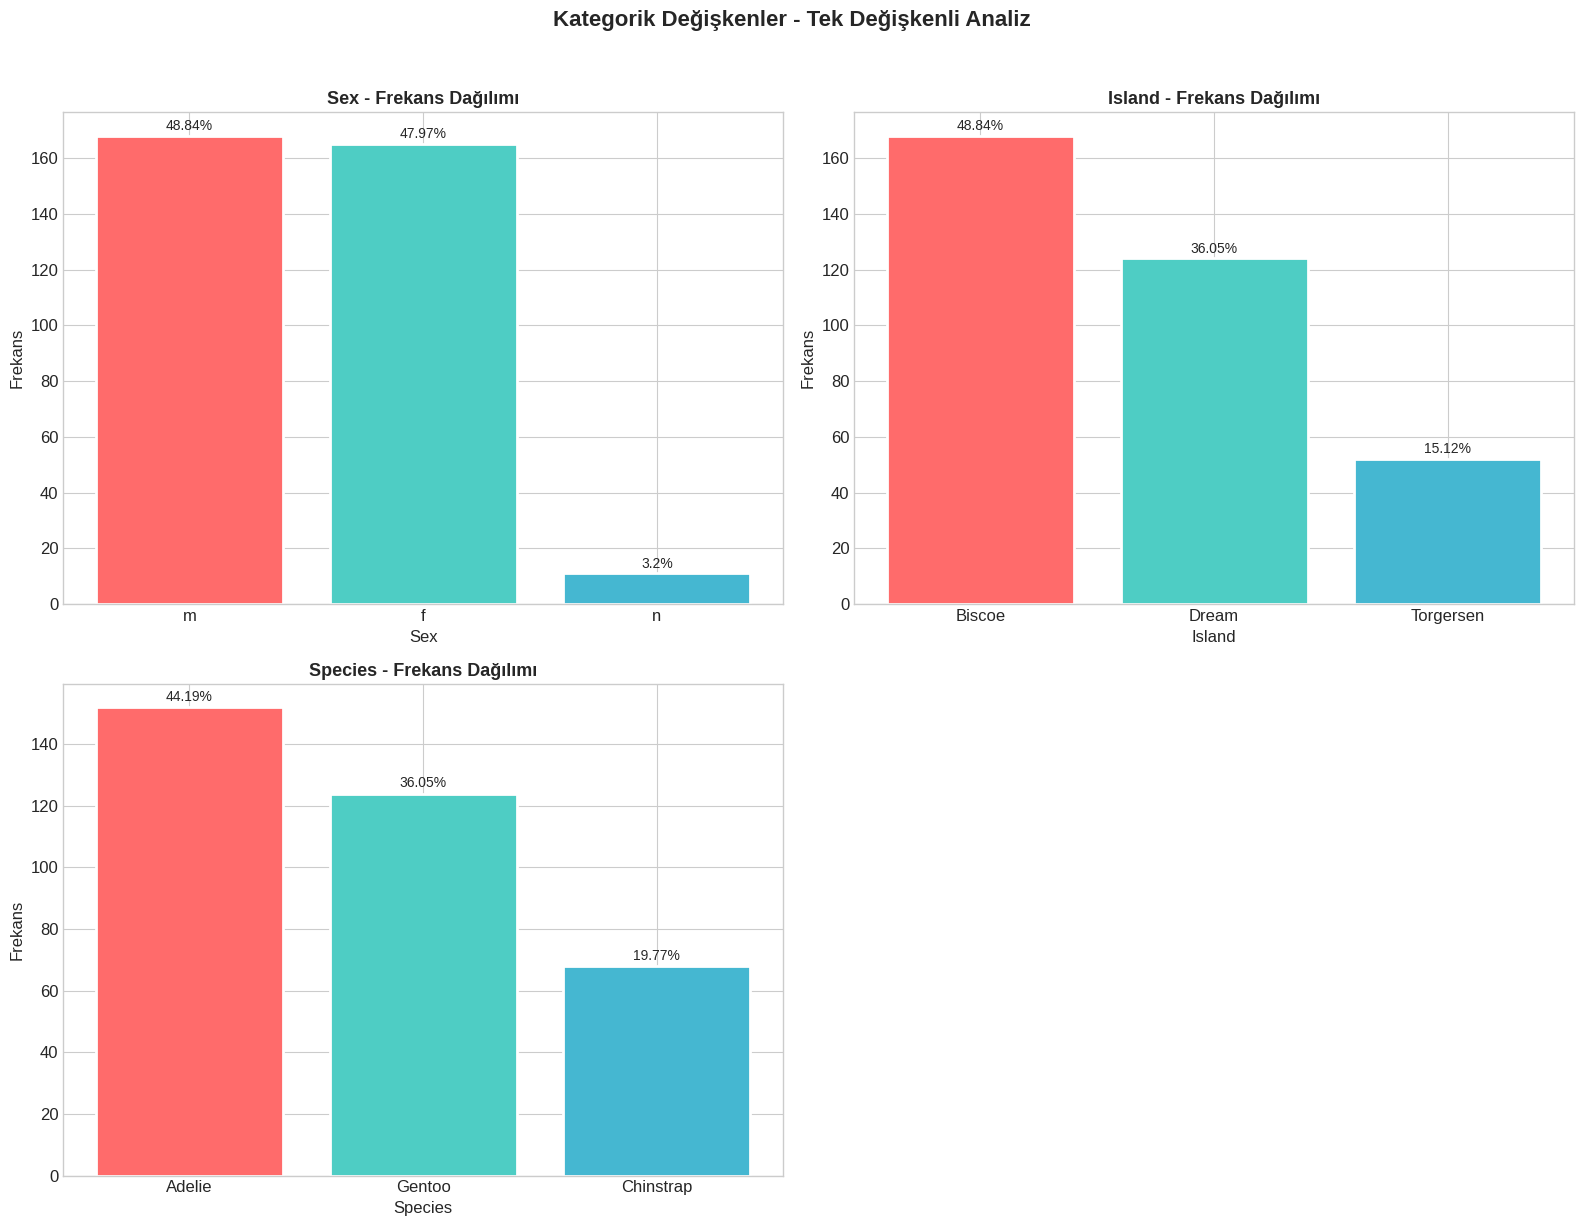

In [ ]:
kategorik_kolonlar = ['sex', 'island', 'species']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_temiz[kolon].value_counts()
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)

    axes[i].set_title(f'{kolon.capitalize()} - Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon.capitalize())
    axes[i].set_ylabel('Frekans')

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1,
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=10)

axes[3].axis('off')

plt.suptitle('Kategorik Değişkenler - Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Çift değişkenli Analiz

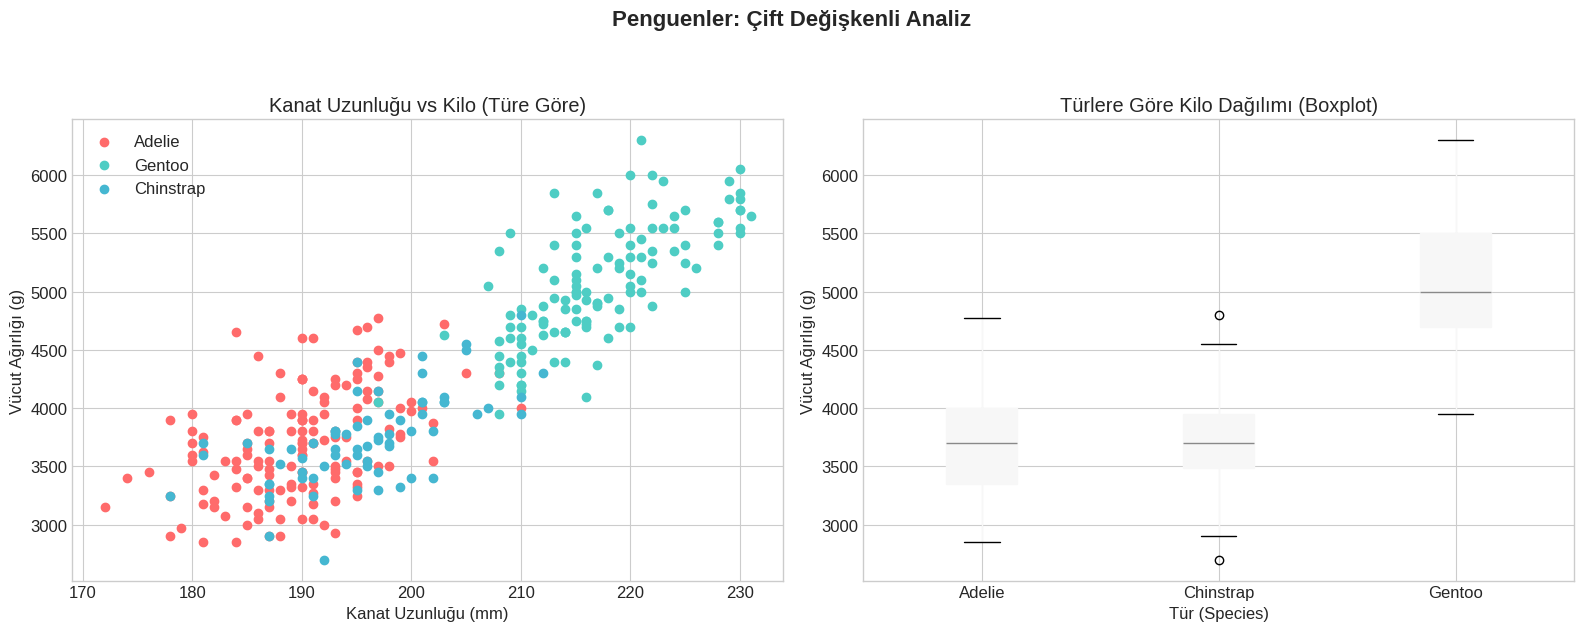

In [ ]:
# Çift Değişkenli Analiz (Bivariate Analysis)

# 1 satır, 2 sütunluk grafik alanı. (16, 6) yan yana duran grafikler için en ideal boyuttur.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. GRAFİK: Kanat Uzunluğu vs Kilo (Sayısal vs Sayısal) ---
# Veriyi türlere göre ayırıyoruz (Titanik'teki survived 1/0 mantığı gibi)
adelie = df_temiz[df_temiz['species'] == 'Adelie']
gentoo = df_temiz[df_temiz['species'] == 'Gentoo']
chinstrap = df_temiz[df_temiz['species'] == 'Chinstrap']

axes[0].scatter(adelie['flipper_length_mm'], adelie['body_mass_g'], color='#FF6B6B', label='Adelie')
axes[0].scatter(gentoo['flipper_length_mm'], gentoo['body_mass_g'], color='#4ECDC4', label='Gentoo')
axes[0].scatter(chinstrap['flipper_length_mm'], chinstrap['body_mass_g'], color='#45B7D1', label='Chinstrap')

axes[0].set_xlabel('Kanat Uzunluğu (mm)')
axes[0].set_ylabel('Vücut Ağırlığı (g)')
axes[0].set_title('Kanat Uzunluğu vs Kilo (Türe Göre)')
axes[0].legend()

# --- 2. GRAFİK: Tür vs Kilo Dağılımı (Kategorik vs Sayısal) ---
# Titanik'teki Pclass vs Fare mantığının aynısı
df_temiz.boxplot(column='body_mass_g', by='species', ax=axes[1], patch_artist=True)

axes[1].set_xlabel('Tür (Species)')
axes[1].set_ylabel('Vücut Ağırlığı (g)')
axes[1].set_title('Türlere Göre Kilo Dağılımı (Boxplot)')

# Pandas boxplot otomatik bir başlık atar, onu ezip kendi ana başlığımızı ekliyoruz
plt.suptitle('Penguenler: Çift Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()